## Key Function: Finding Discrepancies between assigning "Strike" to a pitch location. 

# We then compare the zones provided by the pitch data to find what are assigned the value of "Strike" 
# We also compare the location of the pitch, with the provided strike zone of the batter to assign values of "Strikes"
# We notice a discrepancy between these 2 values in specific cases, which may lead to faulty data quality. 
# We continue to explore these discpencies using further data from the specific pitches. 

In [1]:
### Importing Libraries

import os
import pandas as pd
import numpy as np
import requests
import json
from typing import Dict, Any, Optional, List, Union
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import seaborn as sns
from sklearn.cluster import KMeans
import pybaseball as bb
import datetime
import time
import concurrent.futures

In [2]:
# Defining Functions to Get Pitching Data

# Option 1: Get MLB Stats API data only
# Option 2: Get Statcast data only
# Option 3: Get comprehensive data both datasets

def get_pitcher_stats(player_id: int, season: int) -> Dict[str, Any]:
    """
    Download the pitching statistics for a specific pitcher in a given season using MLB Stats API.
    
    Args:
        player_id (int): The MLB player ID of the pitcher
        season (int): The season year (e.g., 2023)
    
    Returns:
        Dict[str, Any]: Dictionary containing the pitcher's statistics
    """
    # MLB Stats API endpoint for player stats
    url = f"https://statsapi.mlb.com/api/v1/people/{player_id}/stats"
    
    # Parameters for the API request - only get pitching stats
    params = {
        "stats": "season",
        "group": "pitching",  # Only request pitching stats
        "season": str(season),
        "sportId": "1",  # MLB is sportId 1
        "hydrate": "metrics"  # Include additional pitching metrics
    }
    
    try:
        # Make the API request
        response = requests.get(url, params=params)
        response.raise_for_status()  # Raise an exception for bad responses
        
        # Check if player is a pitcher
        data = response.json()
        if not data.get('stats') or not any(stat.get('group', {}).get('displayName') == 'pitching' 
                                          for stat in data.get('stats', [])):
            raise ValueError(f"Player {player_id} does not have pitching statistics")
            
        return data
    
    except requests.exceptions.RequestException as e:
        print(f"Error fetching pitching data: {e}")
        return {}
    except ValueError as e:
        print(e)
        return {}

def get_player_info(player_id: int) -> Dict[str, Any]:
    """
    Get basic information about a player.
    
    Args:
        player_id (int): The MLB player ID
    
    Returns:
        Dict[str, Any]: Dictionary containing the player's information
    """
    url = f"https://statsapi.mlb.com/api/v1/people/{player_id}"
    
    try:
        response = requests.get(url)
        response.raise_for_status()
        return response.json()
    
    except requests.exceptions.RequestException as e:
        print(f"Error fetching player info: {e}")
        return {}

def process_stats(stats_data: Dict[str, Any], category: str) -> Optional[pd.DataFrame]:
    """
    Process the statistics data for a specific category (hitting, pitching, fielding).
    
    Args:
        stats_data (Dict[str, Any]): The statistics data from the API
        category (str): The category of statistics ('hitting', 'pitching', or 'fielding')
    
    Returns:
        Optional[pd.DataFrame]: DataFrame containing the processed statistics, or None if not available
    """
    if not stats_data or 'stats' not in stats_data:
        return None
    
    stats_list = []
    
    # Process all splits and groups to find the category data
    for stat_group in stats_data['stats']:
        group_name = stat_group.get('group', {}).get('displayName', '').lower()
        if group_name == category:
            if 'splits' in stat_group and stat_group['splits']:
                for split in stat_group['splits']:
                    if 'stat' in split:
                        stats_list.append(split['stat'])
    
    if stats_list:
        return pd.DataFrame(stats_list)
    
    return None

def get_all_player_stats(player_id: int, season: int) -> Dict[str, pd.DataFrame]:
    """
    Get all statistics (hitting, pitching, fielding) for a player in a specific season.
    
    Args:
        player_id (int): The MLB player ID
        season (int): The season year
    
    Returns:
        Dict[str, pd.DataFrame]: Dictionary with keys 'hitting', 'pitching', 'fielding' 
                               and corresponding DataFrames as values
    """
    stats_data = get_pitcher_stats(player_id, season)
    player_info = get_player_info(player_id)
    
    result = {}
    
    # Add player basic info
    if player_info and 'people' in player_info and player_info['people']:
        person = player_info['people'][0]
        result['player_info'] = pd.DataFrame([{
            'fullName': person.get('fullName', ''),
            'primaryNumber': person.get('primaryNumber', ''),
            'primaryPosition': person.get('primaryPosition', {}).get('abbreviation', ''),
            'birthDate': person.get('birthDate', ''),
            'currentTeam': person.get('currentTeam', {}).get('name', '') if 'currentTeam' in person else '',
            'height': person.get('height', ''),
            'weight': person.get('weight', '')
        }])
    
    # Process statistics for each category
    for category in ['pitching']:
        df = process_stats(stats_data, category)
        if df is not None:
            result[category] = df
    
    return result

def get_pitcher_statcast(pid: int, year: int) -> pd.DataFrame:
    """
    Get Statcast data for a specific pitcher in a given year.
    
    Args:
        pid (int): The MLB player ID of the pitcher
        year (int): The season year (e.g., 2024)
    
    Returns:
        pd.DataFrame: DataFrame containing the pitcher's Statcast data, or None if no data found/error occurs
    """
    try:
        # Add retry logic
        max_retries = 3
        for attempt in range(max_retries):
            try:
                # Convert year to date range
                start_date = f"{year}-03-01"
                end_date = f"{year}-11-01"
                
                print(f"Fetching Statcast data for pitcher ID {pid} in {year}...")
                
                # Get Statcast data for the pitcher
                df_pitches = bb.statcast_pitcher(start_dt=start_date,
                                       end_dt=end_date,
                                       player_id=pid)
                
                # Add pitcher ID as a column
                if df_pitches is not None and not df_pitches.empty:
                    df_pitches['pitcher_id'] = pid
                    print(f"Successfully retrieved Statcast data for pitcher ID {pid}")
                    return df_pitches
                else:
                    print(f"No Statcast data found for pitcher ID {pid}")
                    return None
                    
            except Exception as e:
                if attempt < max_retries - 1:
                    print(f"Attempt {attempt+1} failed: {e}. Retrying...")
                    time.sleep(2)  # Wait before retry
                else:
                    raise e
                    
    except Exception as e:
        print(f"Error getting Statcast data for pitcher ID {pid}: {e}")
        return None

def display_stats(stats_dict: Dict[str, pd.DataFrame]) -> None:
    """
    Display the statistics in a readable format.
    
    Args:
        stats_dict (Dict[str, pd.DataFrame]): Dictionary of statistics DataFrames
    """
    if 'player_info' in stats_dict:
        info = stats_dict['player_info'].iloc[0]
        print(f"Player: {info['fullName']} (#{info.get('primaryNumber', 'N/A')})")
        print(f"Position: {info.get('primaryPosition', 'N/A')}")
        print(f"Team: {info.get('currentTeam', 'N/A')}")
        print(f"Height: {info.get('height', 'N/A')} | Weight: {info.get('weight', 'N/A')} | DOB: {info.get('birthDate', 'N/A')}")
        print("\n" + "=" * 50 + "\n")
    
    categories = [cat for cat in stats_dict.keys() if cat != 'player_info']
    
    if not categories:
        print("No statistics available for this player in the specified season.")
        return
    
    for category in categories:
        print(f"{category.upper()} STATISTICS:")
        if stats_dict[category].empty:
            print(f"No {category} statistics available.")
        else:
            # Select the most important columns for pitching
            if category == 'pitching':
                columns = ['gamesPlayed', 'gamesStarted', 'inningsPitched', 'wins', 'losses', 'saves', 
                          'era', 'strikeOuts', 'whip', 'hitsPer9Inn', 'homeRunsPer9', 'strikeoutsPer9Inn']
            else:
                columns = stats_dict[category].columns
            
            # Display only columns that exist in the DataFrame
            existing_columns = [col for col in columns if col in stats_dict[category].columns]
            if existing_columns:
                print(stats_dict[category][existing_columns].to_string(index=False))
            else:
                print(stats_dict[category].to_string(index=False))
        
        print("\n" + "=" * 50 + "\n")

def save_stats_to_csv(stats_dict: Dict[str, pd.DataFrame], player_id: int, season: int) -> None:
    """
    Save the statistics to CSV files.
    
    Args:
        stats_dict (Dict[str, pd.DataFrame]): Dictionary of statistics DataFrames
        player_id (int): The MLB player ID
        season (int): The season year
    """
    player_name = "unknown"
    if 'player_info' in stats_dict and not stats_dict['player_info'].empty:
        player_name = stats_dict['player_info']['fullName'].iloc[0].replace(" ", "_")
    
    for category, df in stats_dict.items():
        if category != 'player_info':
            filename = f"{player_name}_{player_id}_{category}_{season}.csv"
            df.to_csv(filename, index=False)
            print(f"Saved {category} statistics to {filename}")

def save_statcast_to_csv(df_statcast: pd.DataFrame, player_id: int, season: int, player_name: str = "unknown") -> None:
    """
    Save Statcast data to CSV file.
    
    Args:
        df_statcast (pd.DataFrame): Statcast DataFrame
        player_id (int): The MLB player ID
        season (int): The season year
        player_name (str): Player's name for filename
    """
    if df_statcast is not None and not df_statcast.empty:
        filename = f"{player_name.replace(' ', '_')}_{player_id}_statcast_{season}.csv"
        df_statcast.to_csv(filename, index=False)
        print(f"Saved Statcast data to {filename}")

def get_comprehensive_pitcher_data(player_id: int, season: int) -> Dict[str, Any]:
    """
    Get both MLB Stats API data and Statcast data for a pitcher.
    
    Args:
        player_id (int): The MLB player ID
        season (int): The season year
    
    Returns:
        Dict[str, Any]: Dictionary containing both types of data
    """
    print(f"\nFetching comprehensive data for pitcher ID {player_id} in the {season} season...\n")
    
    # Get MLB Stats API data
    stats_dict = get_all_player_stats(player_id, season)
    
    # Get Statcast data
    df_statcast = get_pitcher_statcast(player_id, season)
    
    return {
        'stats_api_data': stats_dict,
        'statcast_data': df_statcast,
        'player_id': player_id,
        'season': season
    }

In [3]:
#Retrieving the pitch data from the API
# Currently set to Zach Wheeler's 2022 season. 

# Use pitcher_id from player's MLB.com page. Ex: https://www.mlb.com/player/max-fried-608331 --> Use 608331
pitcher_id = 554430
# Use the year of the season you want to get data for
year = 2022



comprehensive_data = get_comprehensive_pitcher_data(pitcher_id, year)
df_statcast = comprehensive_data['statcast_data']  # Statcast data stored here
df_statcast.head(10)


Fetching comprehensive data for pitcher ID 554430 in the 2022 season...

Fetching Statcast data for pitcher ID 554430 in 2022...
Gathering Player Data
Successfully retrieved Statcast data for pitcher ID 554430


,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,...,api_break_z_with_gravity,api_break_x_arm,api_break_x_batter_in,arm_angle,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches,pitcher_id
0,SI,2022-10-29,94.1,-1.67,5.46,"Wheeler, Zack",493329,554430,field_out,hit_into_play,...,1.77,1.37,1.37,33.2,NaN,NaN,NaN,NaN,NaN,554430
1,FF,2022-10-29,94.6,-1.61,5.50,"Wheeler, Zack",493329,554430,NaN,swinging_strike,...,1.07,0.87,0.87,33.7,NaN,NaN,NaN,NaN,NaN,554430
2,FF,2022-10-29,94.7,-1.67,5.57,"Wheeler, Zack",663656,554430,walk,ball,...,1.06,0.95,-0.95,33.3,NaN,NaN,NaN,NaN,NaN,554430
3,FF,2022-10-29,94.4,-1.59,5.58,"Wheeler, Zack",663656,554430,NaN,ball,...,1.02,0.84,-0.84,35.6,NaN,NaN,NaN,NaN,NaN,554430
4,CH,2022-10-29,89.5,-1.74,5.46,"Wheeler, Zack",663656,554430,NaN,ball,...,2.14,1.31,-1.31,31.6,NaN,NaN,NaN,NaN,NaN,554430
5,CU,2022-10-29,82.4,-1.87,5.51,"Wheeler, Zack",663656,554430,NaN,ball,...,3.87,-0.47,0.47,33.7,NaN,NaN,NaN,NaN,NaN,554430
6,FC,2022-10-29,92.3,-1.72,5.44,"Wheeler, Zack",608324,554430,home_run,hit_into_play,...,1.84,-0.01,-0.01,30.7,NaN,NaN,NaN,NaN,NaN,554430
7,SI,2022-10-29,93.9,-1.71,5.44,"Wheeler, Zack",608324,554430,NaN,ball,...,1.66,1.39,1.39,30.8,NaN,NaN,NaN,NaN,NaN,554430
8,SI,2022-10-29,93.9,-1.87,5.34,"Wheeler, Zack",608324,554430,NaN,ball,...,1.75,1.47,1.47,29.4,NaN,NaN,NaN,NaN,NaN,554430
9,FC,2022-10-29,90.5,-1.73,5.46,"Wheeler, Zack",670541,554430,force_out,hit_into_play,...,2.05,0.08,-0.08,31.2,NaN,NaN,NaN,NaN,NaN,554430


In [4]:
# Standardizing the strike zone to a fixed size, so that we can compare the distribution of pitches in the strike zone to the distribution of pitches in the strike zone. 

# This time, we'll use the strike zone height to standardize the strike zone. 

df_statcast_std = df_statcast.copy()

# Calculate strike zone height for each pitch
df_statcast_std['sz_height'] = df_statcast_std['sz_top'] - df_statcast_std['sz_bot']

# Calculate relative position of plate_z between sz_bot (-100) and sz_top (100)
df_statcast_std['plate_z_scaled'] = (
    (df_statcast_std['plate_z'] - df_statcast_std['sz_bot']) / df_statcast_std['sz_height'] * 200 - 100
)

# Standardize plate_x to -100 to 100 scale
# Strike zone width is approximately 17 inches (-8.5 to 8.5 inches)
df_statcast_std['plate_x_scaled'] = (df_statcast_std['plate_x'] * 12) / 8.5 * 100

df_statcast_std['plate_x_scaled'] = ((100 / 0.83) *df_statcast_std['plate_x'])

print(df_statcast_std[['plate_x', 'plate_x_scaled', 'plate_z', 'plate_z_scaled', 'sz_top', 'sz_bot']].head(25))


    plate_x  plate_x_scaled  plate_z  plate_z_scaled  sz_top  sz_bot
0     -0.92     -110.843373     2.52        0.000000    3.39    1.65
1     -0.05       -6.024096     3.27       86.206897    3.39    1.65
2     -1.12     -134.939759     2.33      -36.898396    3.61    1.74
3     -1.35     -162.650602     2.78       11.229947    3.61    1.74
4     -2.20     -265.060241     3.45       88.950276    3.55    1.74
5     -2.05     -246.987952     2.27      -43.315508    3.61    1.74
6      0.08        9.638554     2.06      -32.926829    3.15    1.51
7     -1.87     -225.301205     1.83      -62.790698    3.23    1.51
8     -1.65     -198.795181     2.29      -10.857143    3.26    1.51
9      0.01        1.204819     2.55       -6.214689    3.49    1.72
10     1.07      128.915663     1.66     -106.349206    3.61    1.72
11     1.81      218.072289     1.58     -119.251337    3.63    1.76
12    -0.21      -25.301205     3.06       39.037433    3.63    1.76
13    -0.06       -7.228916     2.

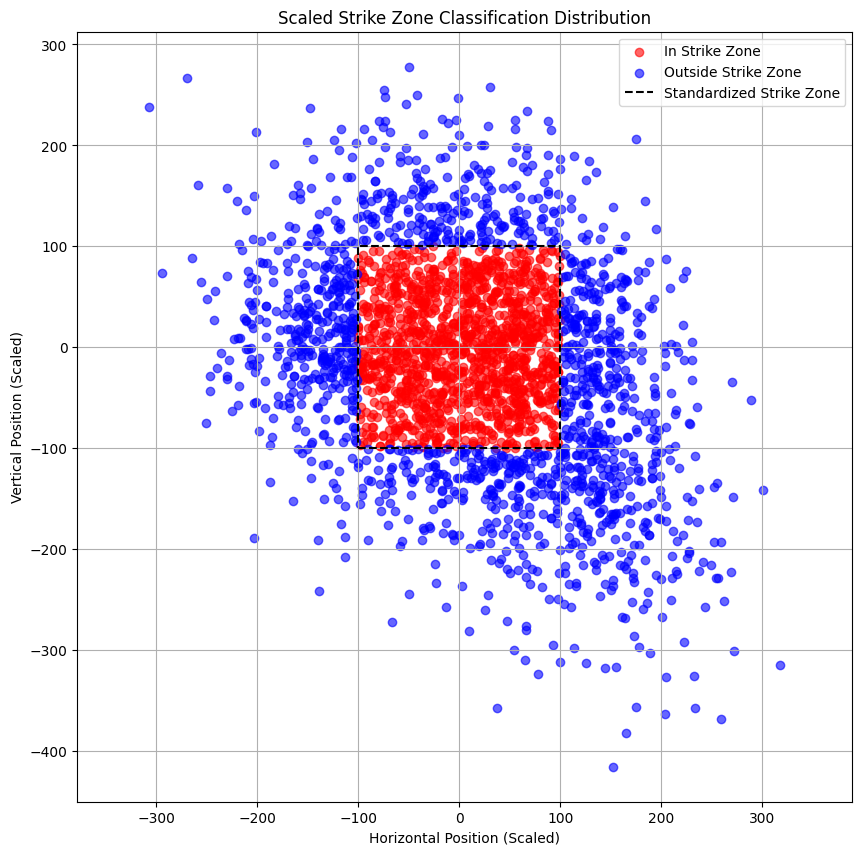

In [8]:
# Create scatter plot of scaled pitch locations with colors based on strike zone
plt.figure(figsize=(10,10))

# Create boolean mask for pitches in strike zone
in_zone = (
    (df_statcast_std['plate_x_scaled'].between(-100, 100)) & 
    (df_statcast_std['plate_z_scaled'].between(-100, 100))
)

# Plot pitches with different colors based on location
plt.scatter(
    df_statcast_std.loc[in_zone, 'plate_x_scaled'],
    df_statcast_std.loc[in_zone, 'plate_z_scaled'],
    c='red',
    alpha=0.6,
    label='In Strike Zone'
)
plt.scatter(
    df_statcast_std.loc[~in_zone, 'plate_x_scaled'], 
    df_statcast_std.loc[~in_zone, 'plate_z_scaled'],
    c='blue',
    alpha=0.6,
    label='Outside Strike Zone'
)

# Draw standardized strike zone (-100 to 100 for both dimensions)
plt.plot([-100, 100, 100, -100, -100], [-100, -100, 100, 100, -100], 'k--', label='Standardized Strike Zone')

# Set axis labels and title
plt.xlabel('Horizontal Position (Scaled)')
plt.ylabel('Vertical Position (Scaled)') 
plt.title('Scaled Strike Zone Classification Distribution')

plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()


